rr# NN_02b — Ablação de Características: Construção Progressiva a partir de ĥ

**Objetivo**: Partir de τ isolado e adicionar características uma a uma, avaliando o ganho marginal de cada parâmetro de canal.  
**Dataset**: `dataset_cnn_yeq_0_30dB.h5` — 350 k amostras, SNR 0–30 dB, canal Rayleigh  
**Avaliação**: D3F com $\alpha = 0{,}01$ (η, extrapolação gaussiana, Braca 2022; alinhado com Xie et al. 2021, Figs. 2-3)  
**Arquitetura**: Dense$(256\to128\to64\to1)$ + BatchNorm + Dropout — mesma para todas as variantes

## Roteiro experimental

| Passo | Variante | Features | # | Hipótese |
|-------|----------|----------|---|----------|
| 1 | **V5** | $[\|\tau\|]$ | 1 | Sem info de canal → deve falhar em baixo SNR |
| 2 | **V6** | $[\|\tau\|, \hat{h}]$ | 2 | Estimativa instantânea de $h$ → melhora esperada |
| 3 | **V7** | $[\|\tau\|, \hat{h}, \overline{\text{SNR}}]$ | 3 | Acrescenta SNR nominal a V6 → redundante? |
| 4 | **V8** | $[\|\tau\|, \hat{h}, E]$ | 3 | Acrescenta energia instantânea a V6 → redundante? |
| 5 | **V1** | $[\|\tau\|, \hat{h}, \overline{\text{SNR}}, E]$ | 4 | Todas as características → redundância além de V6? |

**Expectativa** (orientador): V6 captura o essencial; V7, V8, V1 devem mostrar ganho marginal nulo ou pequeno.

In [1]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from scipy.stats import norm as scipy_norm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Desabilitar XLA JIT (causa travamentos neste ambiente)
tf.config.optimizer.set_jit(False)

print(f"TensorFlow : {tf.__version__}")

# ── GPU Configuration (memory growth evita alocação total de VRAM upfront) ──
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")
USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")
else:
    print("Nenhuma GPU encontrada — executando em CPU.")

np.random.seed(42)
tf.random.set_seed(42)

project_root = Path.cwd().parent
results_dir  = project_root / "results"
data_dir     = results_dir / "data"
models_dir   = results_dir / "models"
vis_dir      = results_dir / "Figures2"
models_dir.mkdir(parents=True, exist_ok=True)
vis_dir.mkdir(parents=True, exist_ok=True)

print(f"\nData    : {data_dir}")
print(f"Models  : {models_dir}")

I0000 00:00:1786964172.066635 1331323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786964172.590815 1331323 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786964176.129073 1331323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).

Data    : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
Models  : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models


In [2]:
# ==============================================================================
# 2. CARREGAR DATASET E EXTRAIR TODAS AS FEATURES
# ==============================================================================
# Features escalares por pacote:
#   tau   = |τ|    — correlador casado (estatística suficiente de Neyman-Pearson)
#   h_est = ĥ_LS   — estimador LS pré-equalização, gerado pelo NN_01 (AÇÃO 2)
#   h_tr  = h      — ganho Rayleigh verdadeiro (para V2: CSI perfeito)
#   snr   = SNR̄   — SNR NOMINAL (pré-fading) do bin de treinamento (AÇÃO 2)
#   E     = E      — mean(y²), energia recebida pré-equalização (AÇÃO 2)

ds_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"
assert ds_path.exists(), f"Dataset não encontrado: {ds_path}"

print("Carregando dataset e extraindo features escalares...")

splits = {}
with h5py.File(str(ds_path), 'r') as f:
    L     = int(f.attrs.get('L_FIXED', 1024))
    RHO_T = float(f.attrs.get('RHO_T', 0.2121))
    RHO_S = float(f.attrs.get('RHO_S', 0.9925))

    for sp in ['train', 'val', 'test']:
        tau   = np.abs(f[f'{sp}/tau_eq'][:]).astype(np.float32) # |τ|
        snr   = f[f'{sp}/snr'][:].astype(np.float32)           # SNR nominal (dB)
        lbl   = f[f'{sp}/y'][:].astype(np.float32)             # 0=H0, 1=H1
        h_tr  = f[f'{sp}/h'][:].astype(np.float32)             # ganho real

        if f'{sp}/h_est' in f and f'{sp}/E' in f:
            # ĥ_LS e E gerados pelo NN_01 (AÇÃO 2: estimador LS, pré-equalização)
            h_est = f[f'{sp}/h_est'][:].astype(np.float32)
            E     = f[f'{sp}/E'][:].astype(np.float32)
        else:
            # Fallback (dataset antigo, sem AÇÃO 2): proxy recomputado de y_eq
            # ATENÇÃO: sob a convenção antiga, h cancela em y_eq — este proxy
            # era na prática um estimador fino de SNR, não de ganho de canal.
            print(f"  ⚠️  {sp}: h_est/E ausentes no HDF5 — usando fallback (dataset pré-AÇÃO 2)")
            Y     = f[f'{sp}/y_eq'][:].astype(np.float32)
            h_est = np.abs(Y).mean(axis=1).astype(np.float32)
            E     = (Y ** 2).mean(axis=1).astype(np.float32)
            del Y

        splits[sp] = {'tau': tau, 'h_est': h_est, 'h_tr': h_tr,
                      'snr': snr, 'E': E, 'lbl': lbl}

print(f"RHO_T={RHO_T:.4f}  RHO_S={RHO_S:.4f}  L={L}")
for sp in ['train', 'val', 'test']:
    n  = len(splits[sp]['lbl'])
    h0 = (splits[sp]['lbl'] == 0).sum()
    h1 = (splits[sp]['lbl'] == 1).sum()
    print(f"  {sp:6s}: {n:,} amostras  (H0={h0:,}  H1={h1:,})")
    print(f"    |τ|: [{splits[sp]['tau'].min():.2f}, {splits[sp]['tau'].max():.2f}]  "
          f"ĥ: [{splits[sp]['h_est'].min():.3f}, {splits[sp]['h_est'].max():.3f}]  "
          f"E: [{splits[sp]['E'].min():.4f}, {splits[sp]['E'].max():.4f}]")

Carregando dataset e extraindo features escalares...
RHO_T=0.2121  RHO_S=0.9925  L=1024
  train : 280,000 amostras  (H0=140,000  H1=140,000)
    |τ|: [0.00, 57262.38]  ĥ: [-0.074, 3.830]  E: [0.0011, 15.2713]
  val   : 35,000 amostras  (H0=17,500  H1=17,500)
    |τ|: [0.00, 5242.22]  ĥ: [-0.021, 3.102]  E: [0.0017, 10.4614]
  test  : 35,000 amostras  (H0=17,500  H1=17,500)
    |τ|: [0.00, 7161.61]  ĥ: [-0.046, 3.244]  E: [0.0016, 11.2137]


In [3]:
# ==============================================================================
# 3. FUNÇÕES AUXILIARES
# ==============================================================================

ALPHA    = 0.01   # η = 0,01 — alinhado com Xie et al. (2021), Figs. 2-3 (ε_FA = 0.01)
Q_INV    = scipy_norm.ppf(1 - ALPHA)   # ≈ 2.326
SNR_BINS = [0, 5, 10, 15, 20, 25, 30]

print(f"D3F: α={ALPHA:.0e}  Q⁻¹(1-α)={Q_INV:.4f}")
print(f"SNR bins: {SNR_BINS}")

def build_features(split_key, feature_keys):
    """Monta matriz X a partir das chaves de features de um split."""
    cols = [splits[split_key][k] for k in feature_keys]
    return np.stack(cols, axis=1) if len(cols) > 1 else cols[0][:, None]

def build_dnn(input_dim):
    """DNN Dense(256→128→64→1) com BatchNorm + Dropout — mesma para todas as variantes."""
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, kernel_initializer='he_uniform')(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64,  kernel_initializer='he_uniform')(x)
    x = layers.Activation('relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=Adam(1e-3), loss=BinaryCrossentropy(),
              metrics=[keras.metrics.AUC(name='auc')])
    return m

def d3f_eval(sc_val, sc_test, snr_val, snr_test, lbl_val, lbl_test):
    """D3F α=η: ajusta N(μ,σ²) em H0 (val), extrapola limiar, mede PD em H1 (test)."""  
    pd = {}
    for snr in SNR_BINS:
        m0 = (snr_val  >= snr-2.5) & (snr_val  < snr+2.5) & (lbl_val  == 0)   #seleciona o conjunto de validacao a partir de H0 dentro de cada bin de SNR. Papel do characterization set.
        m1 = (snr_test >= snr-2.5) & (snr_test < snr+2.5) & (lbl_test == 1)  #seleciona do conjunto de teste a partir de H1 dentro de cada bin de SNR. Papel do test set. Para medr desempenho.
        if m0.sum() < 50 or m1.sum() < 10:
            pd[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd[snr] = 0.0; continue
        pd[snr] = float((sc_test[m1] >= mu + Q_INV * sig).mean())   #calculo da probabilidade de detecção (PD) para cada bin de SNR, usando o limiar obtido a partir da distribuição normal ajustada aos scores do conjunto de validação (H0).
    return pd

# Correlador clássico (referência): mesmo procedimento D3F, aplicado diretamente
# a |τ| (sem rede) — limiar fixo por bin de SNR, calibrado em η=0.01 (Xie 2021).
# Recalculado dinamicamente (não hardcoded) para refletir sempre o η atual.
_pd_classical = d3f_eval(splits['val']['tau'], splits['test']['tau'],
                          splits['val']['snr'], splits['test']['snr'],
                          splits['val']['lbl'], splits['test']['lbl'])
CLASSICAL_PD = {s: round(_pd_classical[s] * 100, 1) for s in SNR_BINS}
print(f"Clássico |τ| (D3F, η={ALPHA:.2f}): "
      + "  ".join(f"{s}dB={CLASSICAL_PD[s]:.1f}%" for s in SNR_BINS))

def train_variant(name, feature_keys, verbose_fit=1):
    """Treina uma variante e retorna dict com PD vs SNR (D3F, α=η)."""
    print(f"\n{'='*65}\n  {name}  |  features: {feature_keys}\n{'='*65}")

    X_tr = build_features('train', feature_keys)
    X_v  = build_features('val',   feature_keys)
    X_te = build_features('test',  feature_keys)

    # z-score normalização (fit no treino)
    mu = X_tr.mean(axis=0); std = X_tr.std(axis=0); std[std < 1e-8] = 1.0
    X_tr_n = ((X_tr - mu) / std).astype(np.float32)
    X_v_n  = ((X_v  - mu) / std).astype(np.float32)
    X_te_n = ((X_te - mu) / std).astype(np.float32)

    model = build_dnn(X_tr.shape[1])
    print(f"  Parâmetros: {model.count_params():,}   Input dim: {X_tr.shape[1]}")

    ckpt = str(models_dir / f"ablation_{name}.keras")
    cbs  = [
        callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=20,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(ckpt, monitor='val_auc', mode='max',
                                  save_best_only=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                    min_lr=1e-6, verbose=0),
    ]

    hist = model.fit(X_tr_n, splits['train']['lbl'],
                     validation_data=(X_v_n, splits['val']['lbl']),
                     epochs=150, batch_size=(512 if USE_GPU else 256), callbacks=cbs, verbose=verbose_fit)

    best_auc = max(hist.history['val_auc'])
    n_ep     = len(hist.history['loss'])

    sc_val  = model.predict(X_v_n,  batch_size=2048, verbose=0).ravel()
    sc_test = model.predict(X_te_n, batch_size=2048, verbose=0).ravel()

    pd = d3f_eval(sc_val, sc_test,
                  splits['val']['snr'], splits['test']['snr'],
                  splits['val']['lbl'], splits['test']['lbl'])

    pd_pct = [round(pd[s]*100, 1) for s in SNR_BINS]
    beats  = ["✓" if pd[s]*100 > CLASSICAL_PD[s] else "✗" for s in SNR_BINS]
    print(f"  Val AUC: {best_auc:.5f}   Épocas: {n_ep}")
    print(f"  PD (%) : {pd_pct}")
    print(f"  > class: {beats}")

    keras.backend.clear_session()
    return {'features': feature_keys, 'n_features': len(feature_keys),
            'best_val_auc': round(best_auc, 5), 'n_epochs': n_ep,
            'pd_vs_snr': {str(s): pd[s] for s in SNR_BINS}}

print("Funções carregadas.")

D3F: α=1e-02  Q⁻¹(1-α)=2.3263
SNR bins: [0, 5, 10, 15, 20, 25, 30]
Clássico |τ| (D3F, η=0.01): 0dB=5.9%  5dB=4.3%  10dB=85.2%  15dB=99.6%  20dB=99.9%  25dB=100.0%  30dB=100.0%
Funções carregadas.


In [4]:
# ==============================================================================
# 4. DEFINIÇÃO DAS VARIANTES E LOOP DE TREINAMENTO
# ==============================================================================
# Roteiro — construção progressiva a partir de ĥ como informação de canal:
#
#   V5 → V6 → V7 / V8 → V1
#
# feature_keys mapeiam para splits[split]['chave']:
#   'tau'   = |τ|    (correlador casado — estatística suficiente NP)
#   'h_est' = ĥ      (estimativa LS do ganho instantâneo)
#   'snr'   = SNR̄   (SNR nominal do bin — info média)
#   'E'     = E      (energia instantânea do sinal recebido)

VARIANT_DEFS = [
    # (nome_interno,   chaves_features,              rótulo para plots)
    ("V5_tau_only",  ['tau'],                       "|τ| isolado  (1 feat)"),
    ("V6_tau_h",     ['tau', 'h_est'],              "[|τ|, ĥ]  (2 feat)"),
    ("V7_h_snr",     ['tau', 'h_est', 'snr'],       "[|τ|, ĥ, SNR̄]  (3 feat)"),
    ("V8_h_energy",  ['tau', 'h_est', 'E'],         "[|τ|, ĥ, E]  (3 feat)"),
    ("V1_baseline",  ['tau', 'h_est', 'snr', 'E'],  "[|τ|, ĥ, SNR̄, E]  (4 feat)"),
]

all_results = {}

for vname, fkeys, _ in VARIANT_DEFS:
    res = train_variant(vname, fkeys, verbose_fit=1)
    all_results[vname] = res

print("\n" + "="*65)
print("TODAS AS VARIANTES CONCLUÍDAS")
print("="*65)


  V5_tau_only  |  features: ['tau']


I0000 00:00:1786964181.308661 1331323 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  Parâmetros: 43,265   Input dim: 1
Epoch 1/150


I0000 00:00:1786964183.962475 1331441 service.cc:153] XLA service 0x75b488037d20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786964183.962510 1331441 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1786964184.021650 1331441 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786964184.441745 1331441 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1786964184.561403 1331441 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2930__.30
I0000 00:00:1786964186.188195 1331441 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 30/547 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9448 - loss: 0.3056

...

547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - auc: 0.9928 - loss: 0.1082 - val_auc: 0.9955 - val_loss: 0.0876 - learning_rate: 0.0010
Epoch 2/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9948 - loss: 0.0895 - val_auc: 0.9957 - val_loss: 0.0856 - learning_rate: 0.0010
Epoch 3/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9950 - loss: 0.0877 - val_auc: 0.9956 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 4/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9952 - loss: 0.0866 - val_auc: 0.9956 - val_loss: 0.0867 - learning_rate: 0.0010
Epoch 5/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9952 - loss: 0.0857 - val_auc: 0.9957 - val_loss: 0.0856 - learning_rate: 0.0010
Epoch 6/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9953 - loss: 0.0849 - val_auc: 0.9957 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 7/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - auc: 0.9953 - loss: 0.0852 - val_auc: 0.9957 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 8/1

I0000 00:00:1786964532.102495 1331442 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314421__.30


538/547 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9829 - loss: 0.1512

I0000 00:00:1786964537.441020 1331436 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_314421__.30


547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - auc: 0.9929 - loss: 0.1077 - val_auc: 0.9956 - val_loss: 0.0845 - learning_rate: 0.0010
Epoch 2/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9951 - loss: 0.0875 - val_auc: 0.9957 - val_loss: 0.0831 - learning_rate: 0.0010
Epoch 3/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9952 - loss: 0.0858 - val_auc: 0.9956 - val_loss: 0.0846 - learning_rate: 0.0010
Epoch 4/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9953 - loss: 0.0847 - val_auc: 0.9956 - val_loss: 0.0840 - learning_rate: 0.0010
Epoch 5/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - auc: 0.9954 - loss: 0.0840 - val_auc: 0.9956 - val_loss: 0.0840 - learning_rate: 0.0010
Epoch 6/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.9954 - loss: 0.0834 - val_auc: 0.9956 - val_loss: 0.0846 - learning_rate: 0.0010
Epoch 7/150
547/547 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.9955 - loss: 0.0832 - val_auc: 0.9956 - val_loss: 0.0840 - learning_rate: 0.0010
Epoch 8/1

In [5]:
# ==============================================================================
# 5. TABELA DE RESULTADOS — PD (%) por SNR bin
# ==============================================================================
LABELS = {d[0]: d[2] for d in VARIANT_DEFS}

header = "  ".join(f"{s:>5}dB" for s in SNR_BINS)
print(f"\n{'Variante':<20}  {'Features':<28}  {header}")
print("-" * 90)

# Correlador clássico
pd_cl = "  ".join(f"{CLASSICAL_PD[s]:>7.1f}" for s in SNR_BINS)
print(f"{'Clássico |τ|':<20}  {'limiar analítico (Xie)':<28}  {pd_cl}  ← referência")
print("-" * 90)

for vname, fkeys, label in VARIANT_DEFS:
    if vname not in all_results:
        continue
    r = all_results[vname]
    pd_row = "  ".join(f"{r['pd_vs_snr'][str(s)]*100:>7.1f}" for s in SNR_BINS)
    pd0    = r['pd_vs_snr']['0'] * 100
    beats  = pd0 > CLASSICAL_PD[0]
    tag    = "  ★" if beats and len(fkeys) <= 2 else ""
    print(f"{vname:<20}  {label:<28}  {pd_row}{tag}")

print("-" * 90)

# Resumo: ganho marginal acima de V6
v6_pd0  = all_results.get('V6_tau_h',    {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v7_pd0  = all_results.get('V7_h_snr',    {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v8_pd0  = all_results.get('V8_h_energy', {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v1_pd0  = all_results.get('V1_baseline', {}).get('pd_vs_snr', {'0': 0})['0'] * 100

print(f"\nGanho marginal a 0 dB sobre V6 ({v6_pd0:.1f}%):")
print(f"  V7 [+SNR̄]  = {v7_pd0:.1f}%  ({v7_pd0-v6_pd0:+.1f} pp)")
print(f"  V8 [+E]    = {v8_pd0:.1f}%  ({v8_pd0-v6_pd0:+.1f} pp)")
print(f"  V1 [+SNR̄+E]= {v1_pd0:.1f}%  ({v1_pd0-v6_pd0:+.1f} pp)")


Variante              Features                          0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clássico |τ|          limiar analítico (Xie)            5.9      4.3     85.2     99.6     99.9    100.0    100.0  ← referência
------------------------------------------------------------------------------------------
V5_tau_only           |τ| isolado  (1 feat)            46.4     88.1     98.1     99.6     99.9    100.0    100.0  ★
V6_tau_h              [|τ|, ĥ]  (2 feat)               54.1     90.0     98.4     99.8    100.0    100.0    100.0  ★
V7_h_snr              [|τ|, ĥ, SNR̄]  (3 feat)         71.9     90.4     98.4     99.6     99.9    100.0    100.0
V8_h_energy           [|τ|, ĥ, E]  (3 feat)            67.7     89.6     98.6     99.8    100.0    100.0    100.0
V1_baseline           [|τ|, ĥ, SNR̄, E]  (4 feat)      69.7     89.4     98.6     99.7     99.9    100.0    100.0

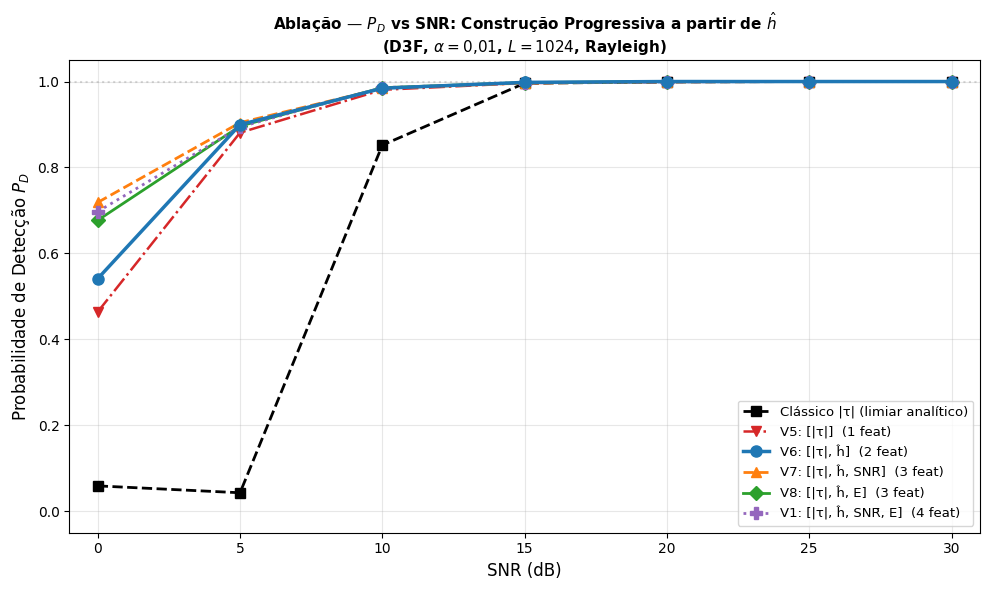

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2/NN02b_ablation_pd_snr.png


In [6]:
# ==============================================================================
# 6. GRÁFICO PD vs SNR — PROGRESSÃO V5 → V6 → V7, V8 → V1
# ==============================================================================

snr_arr = np.array(SNR_BINS)

STYLES = {
    'Clássico':      dict(color='black',   ls='--', lw=2.0, marker='s', ms=7, zorder=5),
    'V5_tau_only':   dict(color='#d62728', ls='-.', lw=1.8, marker='v', ms=7, zorder=4),
    'V6_tau_h':      dict(color='#1f77b4', ls='-',  lw=2.5, marker='o', ms=8, zorder=6),
    'V7_h_snr':      dict(color='#ff7f0e', ls='--', lw=2.0, marker='^', ms=7, zorder=5),
    'V8_h_energy':   dict(color='#2ca02c', ls='-',  lw=2.0, marker='D', ms=7, zorder=5),
    'V1_baseline':   dict(color='#9467bd', ls=':',  lw=2.0, marker='P', ms=8, zorder=5),
}

PLOT_LABELS = {
    'Clássico':    'Clássico |τ| (limiar analítico)',
    'V5_tau_only': 'V5: [|τ|]  (1 feat)',
    'V6_tau_h':    'V6: [|τ|, ĥ]  (2 feat)',
    'V7_h_snr':    'V7: [|τ|, ĥ, SNR̄]  (3 feat)',
    'V8_h_energy': 'V8: [|τ|, ĥ, E]  (3 feat)',
    'V1_baseline': 'V1: [|τ|, ĥ, SNR̄, E]  (4 feat)',
}

fig, ax = plt.subplots(figsize=(10, 6))

# Clássico
st = STYLES['Clássico'].copy(); st['label'] = PLOT_LABELS['Clássico']
ax.plot(snr_arr, [CLASSICAL_PD[s] / 100 for s in SNR_BINS], **st)

# Variantes em ordem narrativa
for vname, _, _ in VARIANT_DEFS:
    if vname not in all_results or vname not in STYLES:
        continue
    pd_arr = [all_results[vname]['pd_vs_snr'][str(s)] for s in SNR_BINS]
    st = STYLES[vname].copy(); st['label'] = PLOT_LABELS[vname]
    ax.plot(snr_arr, pd_arr, **st)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax.set_title(
    f'Ablação — $P_D$ vs SNR: Construção Progressiva a partir de $\\hat{{h}}$\n'
    f'(D3F, $\\alpha=0{{,}}01$, $L=1024$, Rayleigh)',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=9.5, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = vis_dir / "NN02b_ablation_pd_snr.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()
print(f"Figura salva → {fig_path}")

In [7]:
# ==============================================================================
# 7. SALVAR RESULTADOS (JSON) E RESUMO FINAL
# ==============================================================================
out_path = data_dir / "nn02b_ablation_results.json"

save_data = {
    'metadata': {
        'notebook': 'NN_02b',
        'alpha': ALPHA,
        'q_inv': round(Q_INV, 6),
        'snr_bins': SNR_BINS,
        'dataset': 'dataset_cnn_yeq_0_30dB.h5',
        'architecture': 'Dense(256->128->64->1) + BatchNorm + Dropout(0.3,0.3,0.2)',
        'optimizer': 'Adam lr=1e-3',
        'batch_size': 512,
        'max_epochs': 150,
        'early_stopping_patience': 20,
    },
    'classical_correlator': {str(s): CLASSICAL_PD[s] / 100 for s in SNR_BINS},
    'variants': all_results,
}

with open(str(out_path), 'w') as f:
    json.dump(save_data, f, indent=2)
print(f"Resultados salvos → {out_path}")

# --- Resumo narrativo ---
print("\n" + "="*65)
print("RESUMO — PROGRESSÃO DE FEATURES")
print("="*65)

v5 = all_results.get('V5_tau_only',  {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v6 = all_results.get('V6_tau_h',     {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v7 = all_results.get('V7_h_snr',     {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v8 = all_results.get('V8_h_energy',  {}).get('pd_vs_snr', {'0': 0})['0'] * 100
v1 = all_results.get('V1_baseline',  {}).get('pd_vs_snr', {'0': 0})['0'] * 100
cl = CLASSICAL_PD[0]

print(f"\n1. V5 [|τ|] isolado            = {v5:5.1f}%  → falha; sem info de canal")
print(f"   a DNN não aprende limiar adaptativo (mesmo problema do correlador clássico: {cl}%)")
print(f"\n2. V6 [|τ|, ĥ]                 = {v6:5.1f}%  → estimativa instantânea de h resolve")
print(f"   ĥ permite aprender limiares CFAR adaptativos ao ganho do pacote corrente")
print(f"\n3. V7 [|τ|, ĥ, SNR̄]           = {v7:5.1f}%  Δ={v7-v6:+.1f} pp sobre V6")
print(f"   SNR nominal (média do bin) — info redundante quando ĥ já está disponível?")
print(f"\n4. V8 [|τ|, ĥ, E]              = {v8:5.1f}%  Δ={v8-v6:+.1f} pp sobre V6")
print(f"   energia instantânea E — complementar ou redundante a ĥ?")
print(f"\n5. V1 [|τ|, ĥ, SNR̄, E]        = {v1:5.1f}%  Δ={v1-v6:+.1f} pp sobre V6")
print(f"   4 features — expectativa: redundância além de V6")
print(f"\nCONCLUSÃO: verificar se ganhos além de V6 são estatisticamente significativos")

Resultados salvos → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn02b_ablation_results.json

RESUMO — PROGRESSÃO DE FEATURES

1. V5 [|τ|] isolado            =  46.4%  → falha; sem info de canal
   a DNN não aprende limiar adaptativo (mesmo problema do correlador clássico: 5.9%)

2. V6 [|τ|, ĥ]                 =  54.1%  → estimativa instantânea de h resolve
   ĥ permite aprender limiares CFAR adaptativos ao ganho do pacote corrente

3. V7 [|τ|, ĥ, SNR̄]           =  71.9%  Δ=+17.7 pp sobre V6
   SNR nominal (média do bin) — info redundante quando ĥ já está disponível?

4. V8 [|τ|, ĥ, E]              =  67.7%  Δ=+13.6 pp sobre V6
   energia instantânea E — complementar ou redundante a ĥ?

5. V1 [|τ|, ĥ, SNR̄, E]        =  69.7%  Δ=+15.6 pp sobre V6
   4 features — expectativa: redundância além de V6

CONCLUSÃO: verificar se ganhos além de V6 são estatisticamente significativos
